In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None 

import h5py as h5 
from astropy import units as u
from astropy import constants as c
from astropy.cosmology import Planck18


import os
import scipy
from collections import Counter
from collections import defaultdict
import gc
import copy

from sklearn.utils import resample

pd.options.display.max_columns = None

In [2]:
from gwfast          import gwfastGlobals as glob
from gwfast.waveforms import IMRPhenomD
from gwfast.signal    import GWSignal
from gwfast.network   import DetNet
from gwfast.fisherTools import CovMatr

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [3]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
import matplotlib.ticker as ticker

fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "16",
    "xtick.labelsize": "16",
    "ytick.labelsize": "16",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images

from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))


In [4]:
# pop_names = ['notides', 'realistic', 'perfect']
# # pop_names = ['realistic', 'perfect']
# pop_names = ['notides', 'perfect']
pop_names = ['realistic']

pop_paths = {
            'notides': 
                # [
                # '../pop_sims/notides_pop_v329_0_480k.h5',
                # '../pop_sims/notides_pop_v329_480k_960k.h5',
                # '../pop_sims/notides_pop_v329_960k_1440k.h5',
                # '../pop_sims/notides_pop_v329_1440k_1920k.h5',
                # '../pop_sims/notides_pop_v329_1920k_3840k.h5',
                # ],
                ['../pop_sims/notides_pop_v329_combined.h5'],
            
            'realistic':
                # [
                # '../pop_sims/realistic_pop_v329_0_480k.h5',
                # '../pop_sims/realistic_pop_v329_480k_960k.h5',
                # '../pop_sims/realistic_pop_v329_960k_1440k.h5',
                # '../pop_sims/realistic_pop_v329_1440k_1920k.h5',
                # '../pop_sims/realistic_pop_v329_1920k_3840k.h5',
                # ],
                ['../pop_sims/realistic_pop_v329_combined.h5'],
            
            'perfect':
                # [
                # '../pop_sims/perfect_pop_v329_0_480k.h5',
                # '../pop_sims/perfect_pop_v329_480k_960k.h5',
                # '../pop_sims/perfect_pop_v329_960k_1440k.h5',
                # '../pop_sims/perfect_pop_v329_1440k_1920k.h5',
                # '../pop_sims/perfect_pop_v329_1920k_3840k.h5',
                # ]
                ['../pop_sims/perfect_pop_v329_combined.h5'] 
            }

pop_labels = {'notides': 'LEGACY',
              'realistic': 'K26',
              'perfect': 'PERFECT'}

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'perfect': colorPalette['green']}

pop_cmaps = {'notides': 'Reds',
              'realistic': 'Blues',
              'perfect': 'Greens'}

dco_types = ['BBH', 'BHNS', 'BNS']
dco_st = [28, 27, 26]
mt_labels = [
    "No MT", "Stable MT 1→2", "Stable MT 2→1", 
    "CE_Primary", "CE_Secondary", "CE_Both", "MT to Merger"
]
branching_labels = {1: 'Primary', 2: 'Secondary', 3: 'Both', 4: 'MT_to_Merger'}

plot_path = 'pop_plots/'

data_path = 'data_files/'
# if not os.path.exists(plot_path):
#    os.makedirs(plot_path)

In [5]:
st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']
st_labels_plot = ['MS', 'MS', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']
evo_labels = ['', 'Simulation completed', 'Evolution stopped because an error occurred', 'Allowed time exceeded', 'Allowed timesteps exceeded', 
            "No user-provided timesteps read", "User-provided timesteps exhausted", "User-provided timesteps not consumed",
            'SSE error', 'Error evolving binary', 'Time exceeded DCO merger', 
            'Stars touching', 'Merged', 'Stars merged at birth', 
            'DCO formed', 'Double White Dwarf', 'Massless Remnant', 'Unbound binary']

In [8]:
# pop_spin_dfs = {}
# for pop_name in pop_names:
#     pop_spin_dfs[pop_name] = pd.read_csv(data_path + pop_name+'_spin_df.csv') 

# Load and Process Data (skip if running the cell above)

In [ ]:
# def read_zams(fdata):
#     g = fdata['BSE_System_Parameters']
#     return {
#         'SEED':               g['SEED'][...].squeeze(),
#         'Mass@ZAMS(1)':       g['Mass@ZAMS(1)'][...].squeeze(),
#         'Mass@ZAMS(2)':       g['Mass@ZAMS(2)'][...].squeeze(),
#         'Metallicity@ZAMS(1)':g['Metallicity@ZAMS(1)'][...].squeeze(),
#         'Omega(1)':           g['Omega(1)'][...].squeeze(),
#         'Omega(2)':           g['Omega(2)'][...].squeeze(),
#         'Eccentricity@ZAMS':  g['Eccentricity@ZAMS'][...].squeeze(),
#         'SemiMajorAxis@ZAMS': g['SemiMajorAxis@ZAMS'][...].squeeze(),
#         'CH_on_MS(1)':        g['CH_on_MS(1)'][...].squeeze().astype(bool),
#         'CH_on_MS(2)':        g['CH_on_MS(2)'][...].squeeze().astype(bool),
#     }

# def read_dco(fdata):
#     g = fdata['BSE_Double_Compact_Objects']
#     m1 = g['Mass(1)'][...].squeeze()
#     m2 = g['Mass(2)'][...].squeeze()
#     return {
#         'SEED':              g['SEED'][...].squeeze(),
#         'Mass@DCO(1)':       m1,
#         'Mass@DCO(2)':       m2,
#         'SemiMajorAxis@DCO': g['SemiMajorAxis@DCO'][...].squeeze(),
#         'Eccentricity@DCO':  g['Eccentricity@DCO'][...].squeeze(),
#         'Stellar_Type(1)':   g['Stellar_Type(1)'][...].squeeze(),
#         'Stellar_Type(2)':   g['Stellar_Type(2)'][...].squeeze(),
#         'Merges_Hubble_Time':g['Merges_Hubble_Time'][...].squeeze().astype(bool),
#         'Time@DCO':          g['Time'][...].squeeze(),
#         'Coalescence_Time':   g['Coalescence_Time'][...].squeeze(),
#         'M_min@DCO':         np.minimum(m1, m2),
#         'M_max@DCO':         np.maximum(m1, m2),
#     }

# def read_sn(fdata):
#     g = fdata['BSE_Supernovae']
#     sma   = g['SemiMajorAxis<SN'][...].squeeze()
#     m_tot = g['Mass_Total@CO(SN)'][...].squeeze()
#     m_cp  = g['Mass(CP)'][...].squeeze()

#     mt_raw = g['MT_Donor_Hist(SN)'][...].squeeze().astype(str)
#     mt_stripped = np.char.strip(mt_raw)
#     mt_parsed = [
#         list(map(int, s.split('-'))) if s != 'NA' else np.nan
#         for s in mt_stripped
#     ]
#     n_rlof = [len(x) if isinstance(x, list) else 0 for x in mt_parsed]

#     omega_orb = np.sqrt(
#         c.G * (m_tot + m_cp) * u.M_sun / (sma * u.AU)**3
#     ).to(1/u.d)

#     return {
#         'SEED':                    g['SEED'][...].squeeze(),
#         'Time@SN':                 g['Time'][...].squeeze(),
#         'RLOF':                    g['Experienced_RLOF(SN)'][...].squeeze().astype(bool),
#         'Supernova_State':         g['Supernova_State'][...].squeeze(),
#         'SN_Type(SN)':             g['SN_Type(SN)'][...].squeeze(),
#         'Stellar_Type_Prev(SN)':   g['Stellar_Type_Prev(SN)'][...].squeeze(),
#         'Mass_CO_Core@CO(SN)':     g['Mass_CO_Core@CO(SN)'][...].squeeze(),
#         'Mass(SN)':                g['Mass(SN)'][...].squeeze(),
#         'Mass(CP)':                m_cp,
#         'Omega(SN)':               g['Omega(SN)'][...].squeeze(),
#         'SemiMajorAxis<SN':        sma,
#         'Mass_Total@CO(SN)':       m_tot,
#         'Mass_Core@CO(SN)':        g['Mass_Core@CO(SN)'][...].squeeze(),
#         'Radius_Total@CO(SN)':     g['Radius_Total@CO(SN)'][...].squeeze(),
#         'Radius_Core@CO(SN)':      g['Radius_Core@CO(SN)'][...].squeeze(),
#         'MT_Donor_Hist(SN)':       mt_parsed,
#         'Ang_Momentum(SN)':        g['Ang_Momentum(SN)'][...].squeeze(),
#         'SN_Orbit_Inclination_Angle': g['SN_Orbit_Inclination_Angle'][...].squeeze(),
#         'Number_of_RLOF(SN)':      n_rlof,
#         'Orbital_Period<SN':       (2 * np.pi / omega_orb).value,
#     }

# def read_ce(fdata):
#     g = fdata['BSE_Common_Envelopes']
#     return {
#         'SEED':               g['SEED'][...].squeeze(),
#         'MT_History':         g['MT_History'][...].squeeze(),
#         'SemiMajorAxis<CE':   g['SemiMajorAxis<CE'][...].squeeze(),
#         'Eccentricity<CE':    g['Eccentricity<CE'][...].squeeze(),
#         'Mass(1)<CE':         g['Mass(1)<CE'][...].squeeze(),
#         'Mass(2)<CE':         g['Mass(2)<CE'][...].squeeze(),
#         'Stellar_Type(1)<CE': g['Stellar_Type(1)<CE'][...].squeeze(),
#         'Stellar_Type(2)<CE': g['Stellar_Type(2)<CE'][...].squeeze(),
#         'Stellar_Type(1)>CE': g['Stellar_Type(1)'][...].squeeze(),
#         'Stellar_Type(2)>CE': g['Stellar_Type(2)'][...].squeeze(),
#         'Time@CE':            g['Time'][...].squeeze(),
#     }


# def process_file(pop_path):
#     """Read one HDF5 file and return a merged, DCO-filtered DataFrame."""
#     with h5.File(pop_path, 'r') as fdata:
#         zams = pd.DataFrame(read_zams(fdata))
#         dco  = pd.DataFrame(read_dco(fdata))
#         sn   = pd.DataFrame(read_sn(fdata))
#         ce   = pd.DataFrame(read_ce(fdata))

#     # Filter to DCO systems immediately to shed most rows
#     valid_seeds = dco['SEED'].values
#     zams = zams[zams['SEED'].isin(valid_seeds)]
#     sn   = sn[sn['SEED'].isin(valid_seeds)]
#     ce   = ce[ce['SEED'].isin(valid_seeds)]

#     merged = (
#         zams
#         .merge(dco, on='SEED', how='inner')   # inner = only DCO systems
#         .merge(sn,  on='SEED', how='left')
#         .merge(ce,  on='SEED', how='left')
#     )
#     del zams, dco, sn, ce
#     gc.collect()
#     return merged


# def pivot_and_classify(pop_df, branching_labels):
#     ce_columns = [
#         'SEED','MT_History','SemiMajorAxis<CE','Eccentricity<CE',
#         'Mass(1)<CE','Mass(2)<CE','Stellar_Type(1)<CE','Stellar_Type(2)<CE',
#         'Stellar_Type(1)>CE','Stellar_Type(2)>CE','Time@CE',
#     ]
#     sn_columns = [
#         'SEED','Time@SN','RLOF','Supernova_State','SN_Type(SN)',
#         'Stellar_Type_Prev(SN)','Mass_CO_Core@CO(SN)','Mass(SN)','Mass(CP)',
#         'Omega(SN)','SemiMajorAxis<SN','Mass_Total@CO(SN)','Mass_Core@CO(SN)',
#         'Radius_Total@CO(SN)','Radius_Core@CO(SN)','MT_Donor_Hist(SN)',
#         'Ang_Momentum(SN)','SN_Orbit_Inclination_Angle','Number_of_RLOF(SN)',
#         'Orbital_Period<SN',
#     ]

#     # --- CE pivot ---
#     ce_mask = pop_df['MT_History'].between(3, 5)
#     ce_pivot = (
#         pop_df.loc[ce_mask, ce_columns]
#         .pivot_table(index='SEED', columns='MT_History')
#     )
#     ce_pivot.columns = [
#         f'{col[0]}_{branching_labels[int(col[1])-2]}' for col in ce_pivot.columns
#     ]
#     mt_counts = (
#         pop_df.loc[ce_mask, ['SEED', 'MT_History', 'Time@CE']]
#         .pivot_table(index='SEED', columns='MT_History',
#                      values='Time@CE', aggfunc='count', fill_value=0)
#         .astype(bool)
#     )
#     mt_counts.columns = [f'CE_{branching_labels[int(c)-2]}' for c in mt_counts.columns]
#     ce_pivot = ce_pivot.join(mt_counts)
#     del mt_counts

#     # --- SN pivot ---
#     sn_pivot = (
#         pop_df[sn_columns]
#         .pivot_table(index='SEED', columns='Supernova_State', aggfunc='first')
#     )
#     sn_pivot.columns = [
#         f'{col[0]}_{branching_labels[int(col[1])]}' for col in sn_pivot.columns
#     ]
#     for col in ('RLOF_Primary', 'RLOF_Secondary', 'RLOF_Both'):
#         if col in sn_pivot.columns:
#             sn_pivot[col] = sn_pivot[col].astype(bool)

#     # --- Combine ---
#     original_cols = [
#         c for c in pop_df.columns
#         if c not in set(sn_columns + ce_columns) or c == 'SEED'
#     ]
#     result = (
#         pop_df[original_cols]
#         .drop_duplicates(subset=['SEED'])
#         .join(sn_pivot, on='SEED', how='left')
#         .join(ce_pivot, on='SEED', how='left')
#     )
#     del sn_pivot, ce_pivot
#     gc.collect()

#     st1, st2 = result['Stellar_Type(1)'], result['Stellar_Type(2)']
#     result['BBH']  = (st1 + st2 == 28)
#     result['BHNS'] = (st1 + st2 == 27)
#     result['BNS']  = (st1 + st2 == 26)
#     return result


In [ ]:
# # ── Main loop ────────────────────────────────────────────────────────────────
# pop_dfs = {}

# for pop_name in pop_names:
#     print(pop_name)
#     chunks = []

#     for pop_path in pop_paths[pop_name]:
#         chunks.append(process_file(pop_path))
#         gc.collect()

#     pop_df = pd.concat(chunks, ignore_index=True)
#     del chunks
#     gc.collect()

#     pop_dfs[pop_name] = pivot_and_classify(pop_df, branching_labels)
#     del pop_df
#     gc.collect()

#     print()

realistic


/home/vkapil1/.conda/envs/tides_gw/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [18]:
# # Temporary stop gap, because double CEs don't seem to happen with no tides
# for pop_name in pop_names:
#     if 'CE_Both' not in pop_dfs[pop_name]:
#         pop_dfs[pop_name]['CE_Both'] = False
#     if 'CE_Primary' not in pop_dfs[pop_name]:
#         pop_dfs[pop_name]['CE_Primary'] = False

#     pop_dfs[pop_name]['CE_Primary'] = pop_dfs[pop_name]['CE_Primary'].fillna(False)   
#     pop_dfs[pop_name]['CE_Secondary'] = pop_dfs[pop_name]['CE_Secondary'].fillna(False)
#     pop_dfs[pop_name]['CE_Both'] = pop_dfs[pop_name]['CE_Both'].fillna(False)

# pop_dfs['realistic']

In [9]:
ZSOL_ASPLUND = 0.0142

def calculate_dimensionless_spin(m, r, m_remnant, m_core, r_core, omega, metallicity, st):
    m_shell = m - m_core
    j_core = 0.21 * m_core * (r_core**2) * omega
    j_shell = 0.1 * m_shell * (r**2) * omega

    fallback_fraction = np.maximum((m_remnant - m_core)/m_shell, 0)
    fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
    fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

    a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m_remnant)**2)).to(u.dimensionless_unscaled)

    zz = np.sqrt(np.log10(0.1 * ZSOL_ASPLUND/ metallicity))
    c_0 = 0.13 * zz
    c_1 = 0.74 - 0.19*zz
    c_2 = -0.58 + 0.12*zz
    xx = np.log10(m_remnant.value)
    a_max = 10**(c_0 + (c_1*xx) + (c_2 * xx**2))

    J_max = a_max * c.G * (m)**2 / c.c
    a_max_bh = (c.c * J_max / (c.G * (m_remnant)**2)).to(u.dimensionless_unscaled)
    a[a>a_max_bh] = a_max_bh[a>a_max_bh]

    a[a>1.0] = 1.0 # set highly rotating cores to have maximal spin
    a[st < 7] = 0.0 # set non He-burning stars to have 0 spin

    return a, fallback_fraction
        
def return_spin_df(pop_df, dco_type=None, use_omega_orb=False, mergers=True):
    
    if dco_type is not None:
        pop_df = pop_df[pop_df[dco_type]]
    
    if mergers:
        pop_df = pop_df[pop_df["Merges_Hubble_Time"]]
        
    dco_1_mask = (pop_df['SemiMajorAxis<SN_Primary'] > 0)
    dco_both_1_mask = (pop_df['SemiMajorAxis<SN_Both'] > 0) & ~(pop_df['SemiMajorAxis<SN_Primary'] > 0) # Only include if the primary SN has not been recorded

    dco_2_mask = (pop_df['SemiMajorAxis<SN_Secondary'] > 0) 
    dco_both_2_mask = (pop_df['SemiMajorAxis<SN_Both'] > 0) & ~(pop_df['SemiMajorAxis<SN_Secondary'] > 0)# Only include if the secondary SN has not been recorded
    
    metallicity = pop_df['Metallicity@ZAMS(1)'].values
    
    m1 = pop_df["Mass_Total@CO(SN)_Primary"].values * u.M_sun
    r1 = pop_df["Radius_Total@CO(SN)_Primary"].values * u.R_sun
    m1_remnant = pop_df["Mass@DCO(1)"].values * u.M_sun
    m1_core = pop_df["Mass_CO_Core@CO(SN)_Primary"].values * u.M_sun
    r1_core = pop_df["Radius_Core@CO(SN)_Primary"].values * u.R_sun
    period_orb1 = pop_df["Orbital_Period<SN_Primary"].values * u.d
    st1 = pop_df['Stellar_Type_Prev(SN)_Primary']
    omega_orb_1 = (2 * np.pi / period_orb1).to(1/u.yr)
    # omega1 = pop_df["Omega(SN)_Primary"].values / u.yr
    j1 = pop_df['Ang_Momentum(SN)_Primary'].values * u.Msun * u.AU**2 / u.yr
    m1_shell = m1 - m1_core
    I1 = (0.21 * m1_core * (r1_core**2) + 0.1 * m1_shell * (r1**2))
    omega1 = (j1 / I1).to(1/u.yr)       
    
    
    
    m2 = pop_df["Mass_Total@CO(SN)_Secondary"].values * u.M_sun
    r2 = pop_df["Radius_Total@CO(SN)_Secondary"].values * u.R_sun
    m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
    m2_core = pop_df["Mass_CO_Core@CO(SN)_Secondary"].values * u.M_sun
    r2_core = pop_df["Radius_Core@CO(SN)_Secondary"].values * u.R_sun
    period_orb2 = pop_df["Orbital_Period<SN_Secondary"].values * u.d
    st2 = pop_df['Stellar_Type_Prev(SN)_Secondary']
    omega_orb_2 = (2 * np.pi / period_orb2).to(1/u.yr)
    # omega2 = pop_df["Omega(SN)_Secondary"].values / u.yr
    j2 = pop_df['Ang_Momentum(SN)_Secondary'].values * u.Msun * u.AU**2 / u.yr
    m2_shell = m2 - m2_core
    I2 = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))
    omega2 = (j2 / I2).to(1/u.yr)      
    
    
    m3 = pop_df["Mass_Total@CO(SN)_Both"].values * u.M_sun
    r3 = pop_df["Radius_Total@CO(SN)_Both"].values * u.R_sun
    m3_remnant = pop_df["Mass@DCO(1)"].values * u.M_sun
    m3_core = pop_df["Mass_CO_Core@CO(SN)_Both"].values * u.M_sun
    r3_core = pop_df["Radius_Core@CO(SN)_Both"].values * u.R_sun
    period_orb3 = pop_df["Orbital_Period<SN_Both"].values * u.d
    st3 = pop_df['Stellar_Type_Prev(SN)_Both']
    omega_orb_3 = (2 * np.pi / period_orb3).to(1/u.yr)
    # omega3 = pop_df["Omega(SN)_Both"].values / u.yr
    j3 = pop_df['Ang_Momentum(SN)_Both'].values * u.Msun * u.AU**2 / u.yr
    m3_shell = m3 - m3_core
    I3 = (0.21 * m3_core * (r3_core**2) + 0.1 * m3_shell * (r3**2))
    omega3 = (j3 / I3).to(1/u.yr)      
    
    
    # Set the spin assuming synchronicity
    if use_omega_orb == True:
        omega1 = omega_orb_1
        omega2 = omega_orb_2
        omega3 = omega_orb_3

    a1, fb1 = calculate_dimensionless_spin(m1, r1, m1_remnant, m1_core, r1_core, omega1, metallicity, st1)
    a2, fb2 = calculate_dimensionless_spin(m2, r2, m2_remnant, m2_core, r2_core, omega2, metallicity, st2)
    a3, fb3 = calculate_dimensionless_spin(m3, r3, m3_remnant, m3_core, r3_core, omega3, metallicity, st3)
    
    pop_df['a1'] = np.nan
    pop_df['a2'] = np.nan

    pop_df.loc[dco_1_mask, "a1"] = a1[dco_1_mask]
    pop_df.loc[dco_both_1_mask, "a1"] = a3[dco_both_1_mask]
    
    pop_df.loc[dco_2_mask, "a2"] = a2[dco_2_mask]
    pop_df.loc[dco_both_2_mask, "a2"] = a3[dco_both_2_mask]
    
    pop_df['fallback_1'] = np.nan
    pop_df['fallback_2'] = np.nan
    
    pop_df.loc[dco_1_mask, "fallback_1"] = fb1[dco_1_mask]
    pop_df.loc[dco_both_1_mask, "fallback_1"] = fb3[dco_both_1_mask]
    
    pop_df.loc[dco_2_mask, "fallback_2"] = fb2[dco_2_mask]
    pop_df.loc[dco_both_2_mask, "fallback_2"] = fb3[dco_both_2_mask]

    a1, a2, m1, m2 = pop_df["a1"], pop_df["a2"], pop_df["Mass@DCO(1)"], pop_df["Mass@DCO(2)"]
    iota1, iota2, iota2_che = pop_df["SN_Orbit_Inclination_Angle_Primary"], pop_df["SN_Orbit_Inclination_Angle_Secondary"], pop_df["SN_Orbit_Inclination_Angle_Both"]
    iota2 = np.where(np.isnan(iota2), iota2_che, iota2) # If the secondary SN inclination is not recorded, use the "Both" value instead (which should be the same for both SNe)

    pop_df['chi1z'] = a1 * np.cos(iota1)
    pop_df['chi2z'] = a2 * np.cos(iota2)
    
    chi_eff_inclination = ((m1 * a1 * np.cos(iota1)) + (m2 * a2 * np.cos(iota2))) / (m1 + m2)
    pop_df['chi_eff'] = chi_eff_inclination
    
    return pop_df[(~np.isnan(pop_df["a1"]) * ~np.isnan(pop_df["a2"]))]

In [19]:
# pop_spin_dfs = {}
# # pop_spin_omega_dfs = {}

# for pop_name in pop_names:
#     pop_df = pop_dfs[pop_name]
    
#     use_omega_orb = False
#     if pop_name == 'notides':
#         use_omega_orb = True

#     pop_spin_dfs[pop_name] = return_spin_df(pop_df, use_omega_orb=use_omega_orb, mergers=False)


In [20]:
print("Number of BBH mergers in each population:", {pop_name: (pop_df['BBH'] & pop_df['Merges_Hubble_Time']).sum() for pop_name, pop_df in pop_spin_dfs.items()})
print("Number of BNS mergers in each population:", {pop_name: (pop_df['BNS'] & pop_df['Merges_Hubble_Time']).sum() for pop_name, pop_df in pop_spin_dfs.items()})

Number of BBH mergers in each population: {'realistic': 42592}
Number of BNS mergers in each population: {'realistic': 902}


## Assign redshifts

In [21]:
from astropy.cosmology import Planck18
import astropy.units as u
import numpy as np
from scipy.interpolate import interp1d

In [22]:
# ── Pull data from first population ───────────────────────────────────────
first_pop = pop_spin_dfs[pop_names[0]]
bbh = first_pop[first_pop['BBH'] & first_pop['Merges_Hubble_Time']].copy()

Z_form    = bbh['Metallicity@ZAMS(1)'].values          # metallicity at formation
t_delay   = bbh['Time@DCO'].values + bbh['Coalescence_Time'].values                     # delay time in Myr

# ── Langer & Norman 2006: invert Z_mean(z) = 0.035 * 10^(-0.23 * z) ──────
# → z_form = log10(Z / 0.035) / -0.23
mu0, muz  = 0.035, -0.23
z_form    = np.log10(Z_form / mu0) / muz
z_form    = np.clip(z_form, 0, 20)

# ── Build age(z) ↔ z(age) interpolators using Planck18 ────────────────────
z_grid    = np.linspace(0, 20, 10_000)
t_grid    = Planck18.age(z_grid).to(u.Myr).value       # Myr

age_to_z  = interp1d(t_grid[::-1], z_grid[::-1],       # t decreases with z
                     bounds_error=False, fill_value=(20, 0))

# ── Merger redshift: t_merge = t(z_form) + t_delay ────────────────────────
t_form    = Planck18.age(z_form).to(u.Myr).value
t_merge   = t_form + t_delay

t_hubble  = Planck18.age(0).to(u.Myr).value
merges    = t_merge < t_hubble

z_merger  = age_to_z(t_merge)
z_merger[~merges] = np.nan

bbh['z_form']   = z_form
bbh['z_merger'] = z_merger

print(f"Systems:           {len(bbh)}")
print(f"Merges in Hubble:  {merges.sum()}  ({100*merges.mean():.1f}%)")
print(f"z_merger  median:  {np.nanmedian(z_merger):.3f}")
print(f"z_merger  mean:    {np.nanmean(z_merger):.3f}")
print(f"z_merger  < 1:     {(z_merger[merges] < 1).sum()}  ({100*(z_merger[merges]<1).mean():.1f}%)")

KeyError: 'Coalescence_Time'

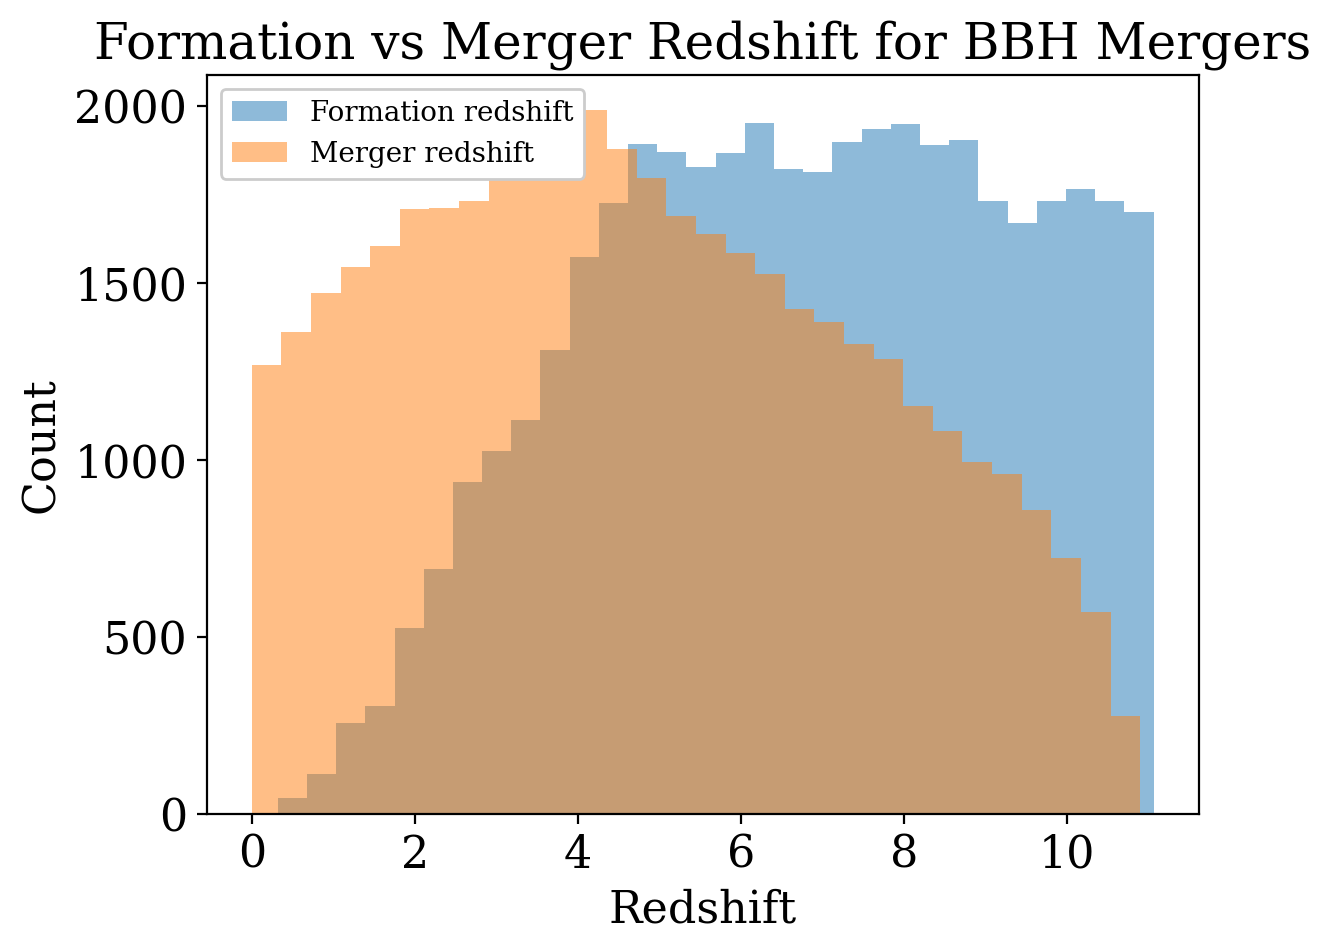

In [ ]:
plt.hist(bbh['z_form'], bins=30, alpha=0.5, label='Formation redshift')
plt.hist(bbh['z_merger'], bins=30, alpha=0.5, label='Merger redshift')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.legend()
plt.title('Formation vs Merger Redshift for BBH Mergers')
plt.show()

# Get SNRs with GWFast

In [7]:
first_pop = pop_spin_dfs[pop_names[0]]
bbh = first_pop[first_pop['BBH'] & first_pop['Merges_Hubble_Time']].copy()

In [8]:
# ── 0. Pull the BBH sample with merger redshifts already computed ─────────
# (bbh DataFrame with z_merger from the previous cell)
sample = bbh[bbh['z_merger'].notna()].copy()

# ── 1. Build O4 H1+L1+Virgo network ──────────────────────────────────────
# gwfast ships O4 ASDs under psds/observing_scenarios_paper/
# filenames from the Iacovelli+2022 observing scenarios paper
O4_psds = {
    'H1':    'aligo_O4high.txt',
    'L1':    'aligo_O4high.txt',
    'Virgo': 'avirgo_O4high_NEW.txt',
}

LVdetectors = {k: copy.deepcopy(glob.detectors[k]) for k in O4_psds}
for det, fname in O4_psds.items():
    LVdetectors[det]['psd_path'] = os.path.join(
        glob.detPath, 'observing_scenarios_paper', fname)

wf = IMRPhenomD()

signals = {
    det: GWSignal(
        wf,
        psd_path      = LVdetectors[det]['psd_path'],
        detector_shape= LVdetectors[det]['shape'],
        det_lat       = LVdetectors[det]['lat'],
        det_long      = LVdetectors[det]['long'],
        det_xax       = LVdetectors[det]['xax'],
        verbose       = True,
        useEarthMotion= False,   # Earth motion negligible for BBH
        fmin          = 10.,
        IntTablePath  = None,
    )
    for det in LVdetectors
}

net = DetNet(signals, verbose=True)

Using ASD from file /home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/psds/observing_scenarios_paper/aligo_O4high.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/psds/observing_scenarios_paper/aligo_O4high.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/psds/observing_scenarios_paper/avirgo_O4high_NEW.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


In [9]:
# ── 2. Build the gwfast event dictionary ─────────────────────────────────
# gwfast IMRPhenomD parameters: Mc, eta, chi1x, chi1y, chi1z, chi2x, chi2y, chi2z,
#                                dL, iota, psi, ra, dec, tcoal, Phicoal
# (non-spin / non-angular params we randomise uniformly — sky pos doesn't matter
#  for population-level SNR statistics, but gwfast needs them)

N = len(sample)
rng = np.random.default_rng(42)

m1  = sample['Mass@DCO(1)'].values   # source-frame M_sun
m2  = sample['Mass@DCO(2)'].values
z   = sample['z_merger'].values

chi1z = sample['a1'].values * np.cos(sample['iota1'].values)          # dimensionless spin aligned with the orbital angular momentum
chi2z = sample['a2'].values * np.cos(sample['iota2'].values)

# detector-frame chirp mass and symmetric mass ratio
Mt  = (m1 + m2) * (1 + z)           # total detector-frame mass
eta = (m1 * m2) / (m1 + m2)**2
Mc  = Mt * eta**0.6                  # detector-frame chirp mass

dL  = Planck18.luminosity_distance(z).to(u.Gpc).value   # gwfast wants Gpc

events = {
    'Mc'     : Mc,
    'eta'    : eta,
    'chi1z'  : chi1z,
    'chi2z'  : chi2z,
    'chi1x'  : np.zeros(N),
    'chi1y'  : np.zeros(N),
    'chi2x'  : np.zeros(N),
    'chi2y'  : np.zeros(N),
    'dL'     : dL,
    'iota'   : np.arccos(rng.uniform(-1, 1, N)),
    'psi'    : rng.uniform(0, 2*np.pi,   N),
    'ra'     : rng.uniform(0, 2*np.pi, N),
    'dec'    : np.arcsin(rng.uniform(-1, 1, N)),
    'tcoal'  : rng.uniform(0, 1, N),          # arbitrary reference GPS / GMST
    'Phicoal': rng.uniform(0, 2*np.pi, N),
}


In [10]:
# ── 3. Compute network SNRs ───────────────────────────────────────────────
snr_net = net.SNR(events, res=1000)   # shape (N,)

sample = sample.copy()
sample['SNR_O4'] = snr_net

print(f"Detectable (SNR > 8):  {(snr_net > 8).sum()} / {N}  "
      f"({100*(snr_net > 8).mean():.1f}%)")
print(f"Median SNR (all):      {np.median(snr_net):.2f}")
print(f"Median SNR (det. only):{np.median(snr_net[snr_net > 8]):.2f}")

Adding (theta, phi) from (ra, dec)
Detectable (SNR > 8):  1378 / 42244  (3.3%)
Median SNR (all):      0.90
Median SNR (det. only):16.35


In [11]:
sample.head()

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,fallback_1,fallback_2,iota1,iota2,chi_eff,SNR_O4
3,268128,39.010147,27.517262,0.000431,0.000000e+00,4.215280,0.103031,7.361368,False,False,14.540433,10.477317,0.073187,0.000000e+00,14,14,True,7.870441,2420.265687,10.477317,14.540433,0.000000e+00,0.000024,NaN,NaN,[4],27.168497,14.540433,NaN,14.540433,10.477317,NaN,10.896358,7.753196,NaN,10.896358,7.753196,NaN,14.540433,10.477317,NaN,0.0,1.0,NaN,0.000000e+00,4.215280,NaN,2275.516426,1.445858,NaN,False,True,True,0.000071,0.000071,NaN,1.223451,1.088017,NaN,0.0,0.000000,NaN,1.0,1.0,NaN,11.741693,0.073187,NaN,8.0,8.0,NaN,5.926063,7.870441,NaN,NaN,0.0,NaN,NaN,14.540433,NaN,NaN,26.682713,NaN,NaN,2219.554480,NaN,NaN,14.0,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,7.0,NaN,NaN,7.772374,NaN,False,True,False,True,False,False,8.303270,2.161509,0.000000e+00,3.472333e-04,1.0,1.000000,0.0,0.000000,1.454197e-04,1.826011
4,268175,35.970528,31.892628,0.000298,1.627510e+01,16313.552933,0.446782,0.417998,False,False,11.720881,20.454058,0.030001,1.110223e-16,14,14,True,8.217540,33.767174,11.720881,20.454058,1.258884e-04,0.685135,NaN,[2],[2],54.247143,11.720881,NaN,11.720621,20.454058,NaN,8.716394,15.607909,NaN,8.716394,15.607909,NaN,11.720621,20.454058,NaN,1.0,1.0,NaN,1.593107e+01,16313.552933,NaN,17.355648,0.334615,NaN,True,True,True,0.000071,0.000071,NaN,1.125913,1.450845,NaN,0.0,0.000000,NaN,1.0,1.0,NaN,0.530077,0.030001,NaN,8.0,8.0,NaN,6.301027,8.217540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False,9.000086,8.517295,1.467983e-03,1.000000e+00,1.0,1.000000,0.0,0.000000,6.362487e-01,0.291076
6,268238,48.064860,30.451258,0.004016,8.120247e-12,79273.811473,0.060893,3.191490,False,False,15.403003,6.322088,0.048608,2.602534e-01,14,1

In [ ]:
fig, ax = plt.subplots(ncols=1, figsize=(6, 3))

dco_type = 'BBH'

pop_spin_df = sample

a1, a2, m1, m2 = pop_spin_df["a1"], pop_spin_df["a2"], pop_spin_df["Mass@DCO(1)"], pop_spin_df["Mass@DCO(2)"]
chi_eff_inclination = pop_spin_df['chi_eff']
snr_o4 = pop_spin_df['SNR_O4']

bins = np.linspace(-0.05, 1.05, 28)
ax.hist(chi_eff_inclination, bins=bins, density=True, alpha=0.8, histtype='step', lw=3, linestyle='-', label='K26', color=pop_colors['blue'])
ax.hist(chi_eff_inclination[snr_o4>8], bins=bins, density=True, alpha=0.8, histtype='step', lw=3, linestyle='-', label='K26, $SNR_{\\rm O4a}$ > 8', color=pop_colors['violet'])


print(pop_labels[pop_name])
print(f"Minimally spinning BBH: {np.sum(chi_eff_inclination<0.2)} / {len(chi_eff_inclination)} ({100 * np.sum(chi_eff_inclination<0.2)/len(chi_eff_inclination):.2f}%)")
print(f"Paritally spinning BBH: {np.sum((chi_eff_inclination>0.2) * (chi_eff_inclination<0.75))} / {len(chi_eff_inclination)} ({100 * np.sum(((chi_eff_inclination>0.2) * (chi_eff_inclination<0.75)))/len(chi_eff_inclination):.2f}%)")
print(f"Maximally spinning BBH: {np.sum(chi_eff_inclination>0.75)} / {len(chi_eff_inclination)} ({100 * np.sum(chi_eff_inclination>0.75)/len(chi_eff_inclination):.2f}%)")
print()

# ax.set_title(dco_type, fontsize=20)
ax.set_xlabel('$\chi_{\\rm{eff}}$', fontsize=20)
ax.set_ylabel('P$(\chi_{\\rm{eff}})$', fontsize=20)
# ax.legend(fontsize=20)
ax.set_xticks(ticks=np.linspace(0, 1, 6))
# ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.grid()

ax.legend(fontsize=14, loc=(0.6, 0.45))

plt.tight_layout()
# plt.savefig(plot_path+'chi_eff_k26_snr_o4.pdf', dpi=300, bbox_inches='tight')
plt.show()

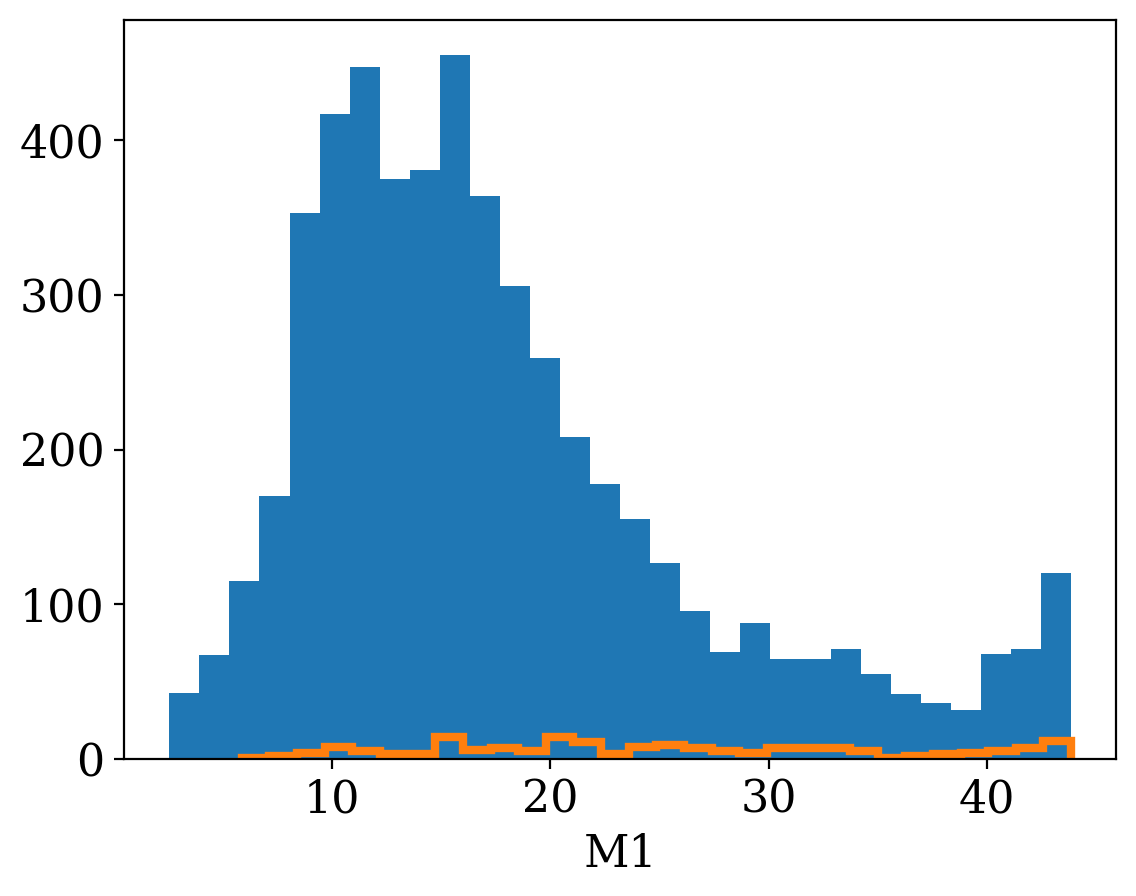

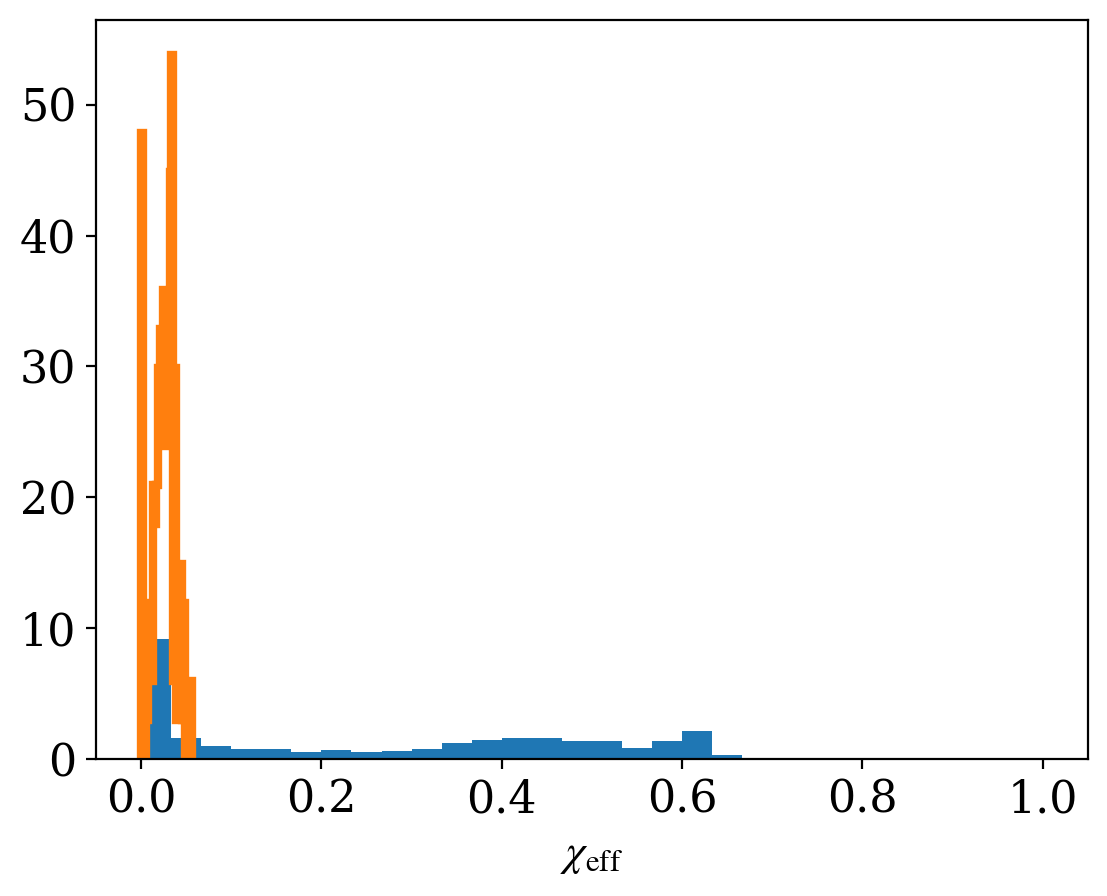

In [ ]:
plt.hist(sample[sample['SNR_O4']>0]['M_max@DCO'], bins=30, density=False)
plt.hist(sample[sample['SNR_O4']>8]['M_max@DCO'], bins=30, density=False, histtype='step', lw=3)
plt.xlabel("M1")
plt.show()


plt.hist(sample[sample['SNR_O4']>0]['chi_eff'], bins=30, density=True)
plt.hist(sample[sample['SNR_O4']>8]['chi_eff'], bins=30, density=True, histtype='step', lw=3)
plt.xlabel("$\\chi_{\\text{eff}}$")
plt.show()

# Covariance

In [ ]:
# ── 4. Compute Fisher matrices and covariances (detectable subset only) ───
det_mask   = snr_net > 8
det_events = {k: v[det_mask] for k, v in events.items()}

# FisherMatr returns shape (n_params, n_params, N_det)
FIM = net.FisherMatr(det_events, res=1000)

# CovMatr inverts the Fisher matrix with condition-number checks
# returns covariance (n_params, n_params, N_det) + inversion error array
cov, inv_err = CovMatr(FIM)


Computing Fisher for H1...
Computing derivatives...


In [1]:
# ── 5. Extract 1-sigma parameter errors ───────────────────────────────────
ParNums = wf.ParNums   # dict: param_name → row/col index in Fisher matrix

sigma_Mc  = np.sqrt(cov[ParNums['Mc'],  ParNums['Mc'],  :])   # Gpc (det-frame)
sigma_eta = np.sqrt(cov[ParNums['eta'], ParNums['eta'], :])
sigma_dL  = np.sqrt(cov[ParNums['dL'],  ParNums['dL'],  :])   # Gpc
sigma_chi1z = np.sqrt(cov[ParNums['chi1z'], ParNums['chi1z'], :])
sigma_chi2z = np.sqrt(cov[ParNums['chi2z'], ParNums['chi2z'], :])
results = pd.DataFrame({
    'SNR'         : snr_net[det_mask],
    'Mc_det'      : Mc[det_mask],
    'dL_Gpc'      : dL[det_mask],
    'z_merger'    : z[det_mask],
    'sigma_Mc'    : sigma_Mc,
    'sigma_eta'   : sigma_eta,
    'sigma_dL'    : sigma_dL,
    'rel_err_Mc'  : sigma_Mc  / Mc[det_mask],
    'rel_err_dL'  : sigma_dL  / dL[det_mask],
    'inv_err'     : inv_err,
    'sigma_chi1z' : sigma_chi1z,
    'sigma_chi2z' : sigma_chi2z,
}, index=sample.index[det_mask])

print(results[['SNR','z_merger','rel_err_Mc','rel_err_dL']].describe().round(4))

NameError: name 'wf' is not defined

# Load ALL Fisher results

In [6]:
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
from scipy.stats import norm

In [54]:
# net_name = 'O4a'
net_name = '3G'

SNR_THRESHOLD = 8

In [55]:

# ── Load data ────────────────────────────────────────────────────────────────
filepath = f"data_files/{net_name}_gwfast.h5"

with h5.File(filepath, "r") as f:
    # events (full injection set)
    chi1z_all   = f["events/chi1z"][:]
    chi2z_all   = f["events/chi2z"][:]
    
    eta_all     = f["events/eta"][:]
    
    # detectable subset indices
    det_indices = f["det_indices"][:]
    
    # covariance matrix (n_params, n_params, N_det)
    cov         = f["cov"][:]
    
    # param names to find chi1z index
    param_names = list(f["metadata/param_names"].asstr()[:])
    

In [56]:
print('Network:', net_name)
print()

# ── Extract chi1z injected values + std devs for detectable events ───────────
chi1z_det  = chi1z_all[det_indices]                    # injected values (means)
chi1z_idx  = param_names.index("chi1z")
chi1z_vars = cov[chi1z_idx, chi1z_idx, :]             # diagonal = variance
chi1z_stds = np.sqrt(np.abs(chi1z_vars))              # std dev per event
print(f"Detectable events : {len(chi1z_det)}")
print(f"Median injected chi1z : {np.median(chi1z_det):.3f}")
print(f"Median sigma(chi1z)   : {np.median(chi1z_stds):.4f}")

print()

chi2z_det  = chi2z_all[det_indices]                    # injected values (means)
chi2z_idx  = param_names.index("chi2z")
chi2z_vars = cov[chi2z_idx, chi2z_idx, :]             # diagonal = variance
chi2z_stds = np.sqrt(np.abs(chi2z_vars))              # std dev per event
print(f"Detectable events : {len(chi2z_det)}")
print(f"Median injected chi2z : {np.median(chi2z_det):.3f}")
print(f"Median sigma(chi2z)   : {np.median(chi2z_stds):.4f}")

Network: 3G

Detectable events : 40727
Median injected chi1z : 0.000
Median sigma(chi1z)   : 9.0855

Detectable events : 40727
Median injected chi2z : 0.490
Median sigma(chi2z)   : 0.0468


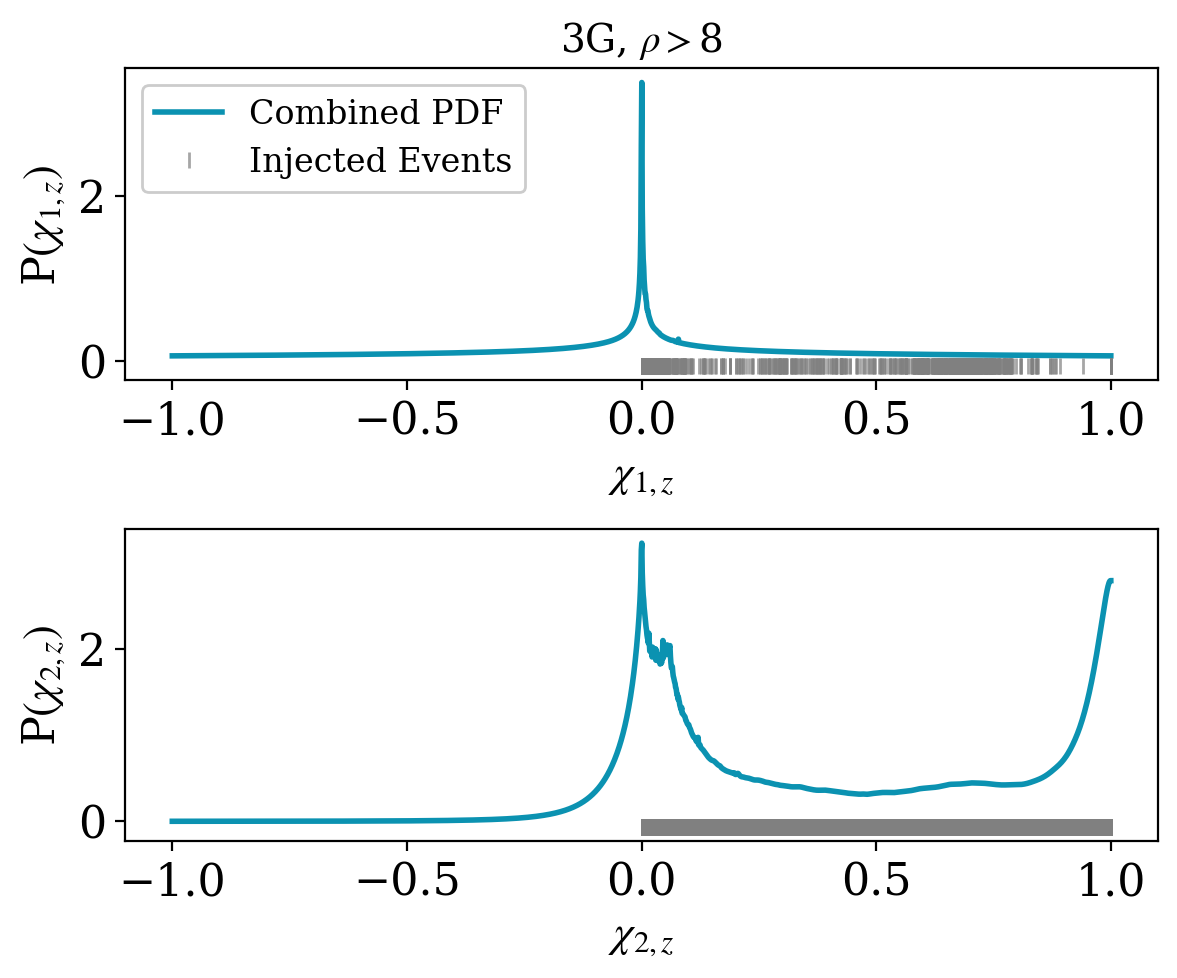

In [57]:
x = np.linspace(-1, 1, 2000)

# ── Compute per-event Gaussians and combined PDF ──────────────────────────────
# gaussians shape: (N_det, len(x))
gaussians1 = (
    1.0 / (chi1z_stds[:, None] * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x[None, :] - chi1z_det[:, None]) / chi1z_stds[:, None]) ** 2)
)

combined_pdf1 = gaussians1.mean(axis=0)    # average over events → population PDF

gaussians2 = (
    1.0 / (chi2z_stds[:, None] * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x[None, :] - chi2z_det[:, None]) / chi2z_stds[:, None]) ** 2)
)

combined_pdf2 = gaussians2.mean(axis=0)    # average over events → population PDF

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=2, figsize=(6, 5))

# for i in range(len(chi1z_det)):
#     axes[0].plot(x, gaussians1[i], color="steelblue", alpha=0.15, linewidth=0.7)
    # axes[1].plot(x, gaussians2[i], color="steelblue", alpha=0.15, linewidth=0.7)

axes[0].plot(x, combined_pdf1, color=colorPalette['blue'], linewidth=2, label="Combined PDF")
axes[1].plot(x, combined_pdf2, color=colorPalette['blue'], linewidth=2, label="Combined PDF")


# Mark injected values as rug plot on x-axis
axes[0].plot(chi1z_det, np.full_like(chi1z_det, -0.02 * combined_pdf1.max()),
        "|", color="gray", alpha=0.7, markersize=6, label=r"Injected Events")

axes[1].plot(chi2z_det, np.full_like(chi2z_det, -0.02 * combined_pdf2.max()),
        "|", color="gray", alpha=0.7, markersize=6, label=r"Injected Events")

axes[0].set_title(f"{net_name}, $\\rho >${SNR_THRESHOLD}", fontsize=14)

ax = axes[0]
ax.set_xlabel(r"$\chi_{1,z}$")
ax.set_ylabel(r"P$(\chi_{1,z})$")
ax.legend(loc='upper left', fontsize=12)
# ax.set_xlim(-0.4, 0.4)
# ax.set_yscale('log')

ax = axes[1]
ax.set_xlabel(r"$\chi_{2,z}$")
ax.set_ylabel(r"P$(\chi_{2,z})$")
# ax.legend(loc='upper left', fontsize=12)
# ax.set_xlim(-0.4, 0.4)
# ax.set_yscale('log')

plt.tight_layout()
# plt.savefig(f"pop_plots/{net_name}_chi1z_chi2z_posteriors.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [58]:
eta_det   = eta_all[det_indices]

# ── Injected chi_eff ──────────────────────────────────────────────────────────
# chi_eff = w1*chi1z + w2*chi2z  where weights come from mass ratio
# eta = q/(1+q)^2,  solving: w1 = (1 + sqrt(1-4eta))/2
disc   = np.sqrt(np.clip(1 - 4 * eta_det, 0, None))   # clip for eta ~ 0.25
w1_det = (1 + disc) / 2                                # weight for chi1z (primary)
w2_det = (1 - disc) / 2                                # weight for chi2z (secondary)

chieff_det = w1_det * chi1z_det + w2_det * chi2z_det


# ── Jacobian of chi_eff w.r.t. (chi1z, chi2z, eta) ───────────────────────────
# d(chi_eff)/d(chi1z) = w1
# d(chi_eff)/d(chi2z) = w2
# d(chi_eff)/d(eta)   = (chi2z - chi1z) / (2 * sqrt(1 - 4*eta))
dchieff_dchi1z = w1_det
dchieff_dchi2z = w2_det
dchieff_deta   = (chi2z_det - chi1z_det) / (2 * np.where(disc == 0, np.inf, disc))



In [59]:
# ── Extract relevant covariance sub-blocks ────────────────────────────────────
# cov shape: (n_params, n_params, N_det)
i_chi1z = param_names.index('chi1z')
i_chi2z = param_names.index('chi2z')
i_eta   = param_names.index('eta')

var_chi1z  = cov[i_chi1z, i_chi1z, :]
var_chi2z  = cov[i_chi2z, i_chi2z, :]
var_eta    = cov[i_eta,   i_eta,   :]
cov_12     = cov[i_chi1z, i_chi2z, :]    # cov(chi1z, chi2z)
cov_1eta   = cov[i_chi1z, i_eta,   :]    # cov(chi1z, eta)
cov_2eta   = cov[i_chi2z, i_eta,   :]    # cov(chi2z, eta)

# ── Error propagation ─────────────────────────────────────────────────────────
J1  = dchieff_dchi1z
J2  = dchieff_dchi2z
Jn  = dchieff_deta

var_chieff = (
      J1**2 * var_chi1z
    + J2**2 * var_chi2z
    + Jn**2 * var_eta
    + 2 * J1 * J2 * cov_12
    + 2 * J1 * Jn * cov_1eta
    + 2 * J2 * Jn * cov_2eta
)
chieff_stds = np.sqrt(np.abs(var_chieff))


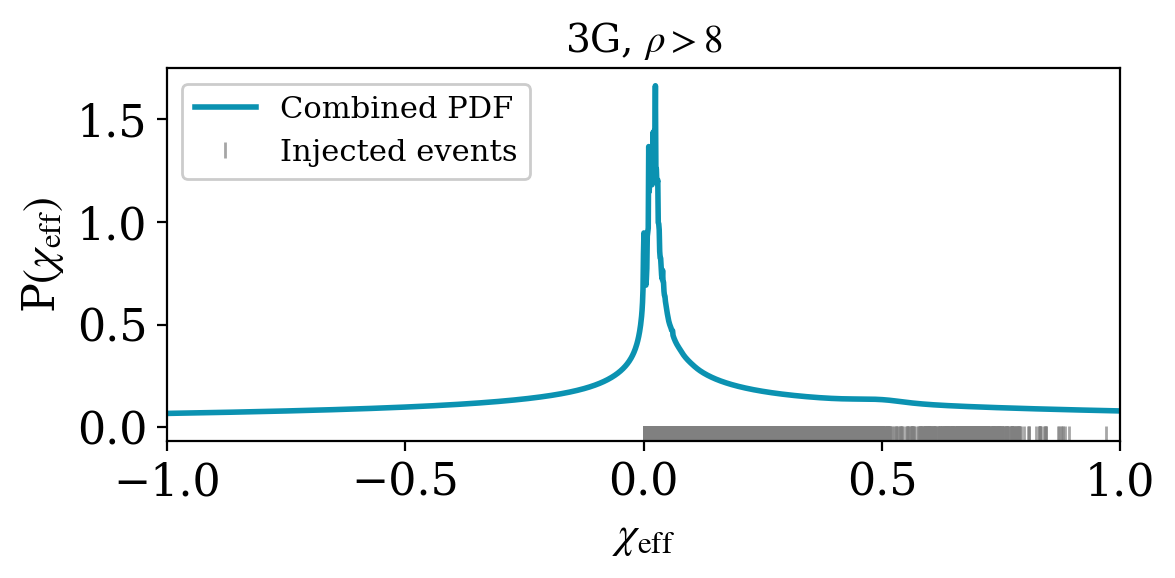

In [60]:
# ── Build Gaussians ───────────────────────────────────────────────────────────
xe = np.linspace(-1, 1, 2000)      # chi_eff domain

gaussians_eff = (
    1.0 / (chieff_stds[:, None] * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((xe[None, :] - chieff_det[:, None]) / chieff_stds[:, None]) ** 2)
)
combined_pdf_eff = gaussians_eff.mean(axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(nrows=1, figsize=(6, 3))

ax.plot(xe, combined_pdf_eff, color=colorPalette['blue'],
        linewidth=2, label="Combined PDF")
ax.plot(chieff_det,
        np.full_like(chieff_det, -0.02 * combined_pdf_eff.max()),
        "|", color="gray", alpha=0.7, markersize=6, label="Injected events")
ax.set_xlabel(xlabel)
ax.set_ylabel(rf"P$({xlabel.strip('$')})$")

ax.set_xlim(xe[0], xe[-1])
ax.set_ylim(bottom=-0.04 * combined_pdf_eff.max())

# ax.set_yscale('log')

ax.set_title(f"{net_name}, $\\rho > {SNR_THRESHOLD}$", fontsize=14)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(f"pop_plots/{net_name}_chi_eff_posteriors.pdf", dpi=300, bbox_inches='tight')
plt.show()

